In [16]:
from fiatlux.optical_elements.mask import CircularAperture
from fiatlux.grid import Grid
from fiatlux.spectrum import *
from fiatlux.source import *
from fiatlux.propagator import MFTPropagator
from fiatlux.optical_elements.mask import ZeldaMask, FieldStop, ZeldaStop
from fiatlux.utils.converter import FocalPlaneConverter


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [17]:
spectrum = Spectrum.from_sampling(PhotometricBand.I4, Nu=512)

# System parameters
f = 0.125
lambda_max = spectrum.wavelengths.max()
D = 10

source = PlaneWave(
    spectrum=spectrum,
    incidence_angle=IncidenceAngle(tip=0, tilt=(8 * 2 * torch.pi * lambda_max / D)),
)

theta = lambda_max / 4

# Pupil plane sampling
Nx = Ny = 128
dx = dy = D / Nx
pupil_grid = Grid(nx=Nx, ny=Ny, dx=dx, dy=dx)

# Focal plane sampling
Nu = Nv = 512
# # Shanon
# du = dv = Nx * (f * l / D) / Nu
du = dv = (10) * (f * lambda_max / D) / (Nu / 2)
focal_grid = Grid(nx=Nu, ny=Nv, dx=du, dy=dv)

# Create aperture
aperture = CircularAperture(radius=D / 2)
aperture.build(pupil_grid)

# Define propagator
mft = MFTPropagator(focal_length=f)

# Define zelda mask
zelda_mask = ZeldaMask(radius=f * lambda_max / D, well_depth=theta)
zelda_mask.build(grid=focal_grid, spectrum=spectrum)

zelda_stop = ZeldaStop(radius=f * lambda_max / D, well_depth=theta)
zelda_stop.build(grid=focal_grid)

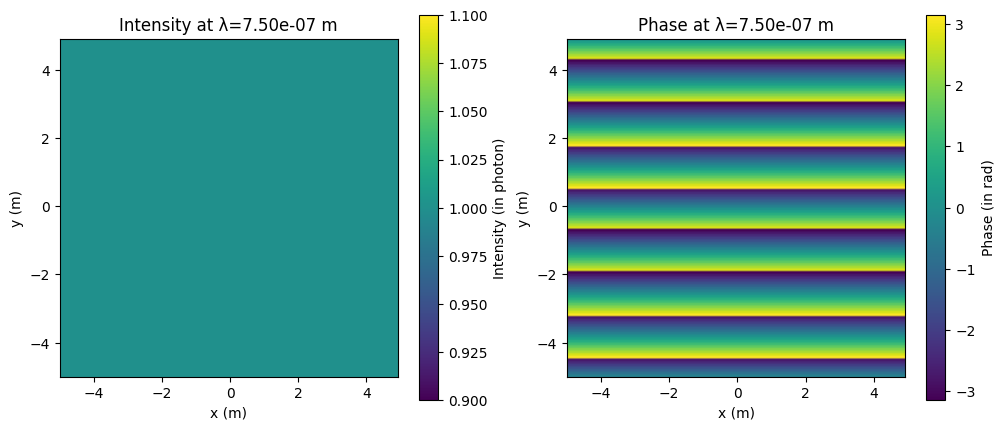

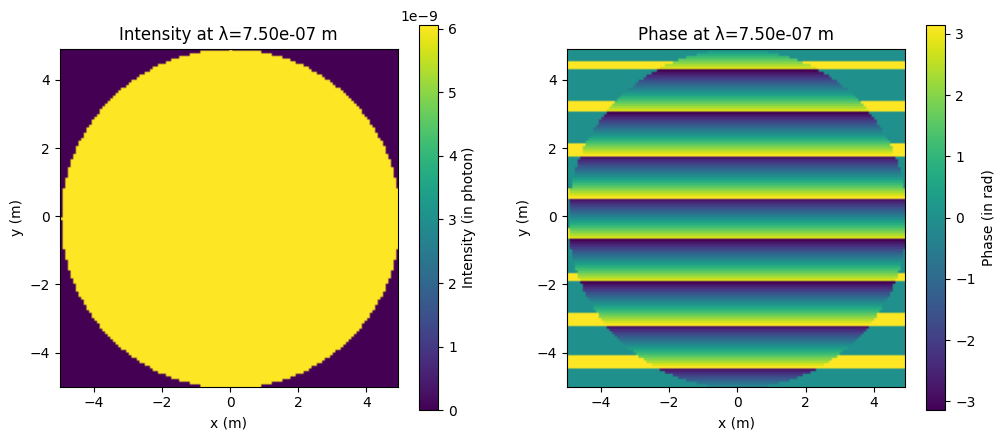

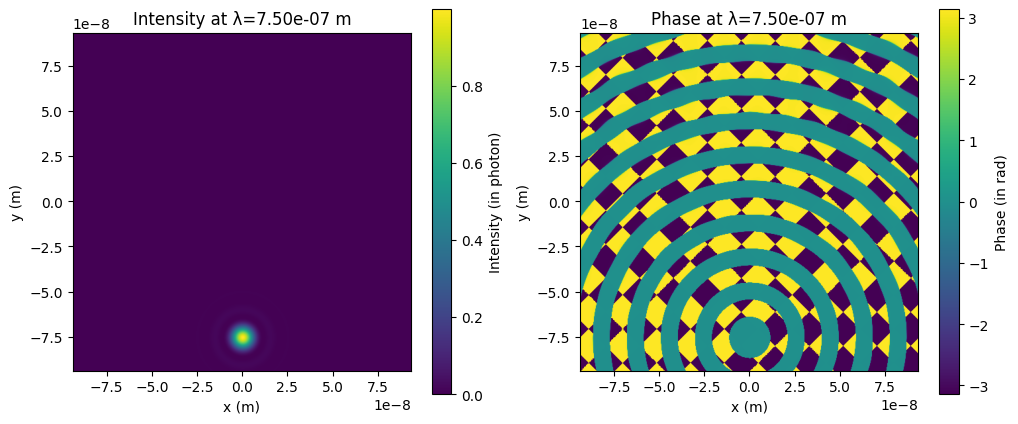

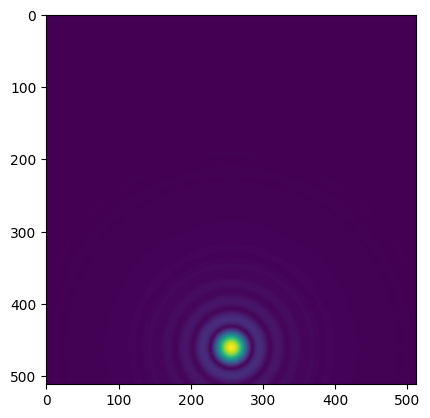

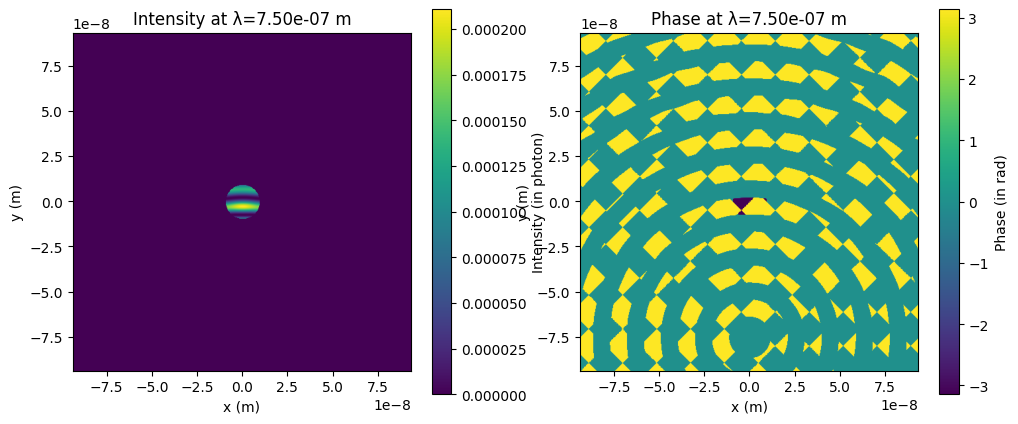

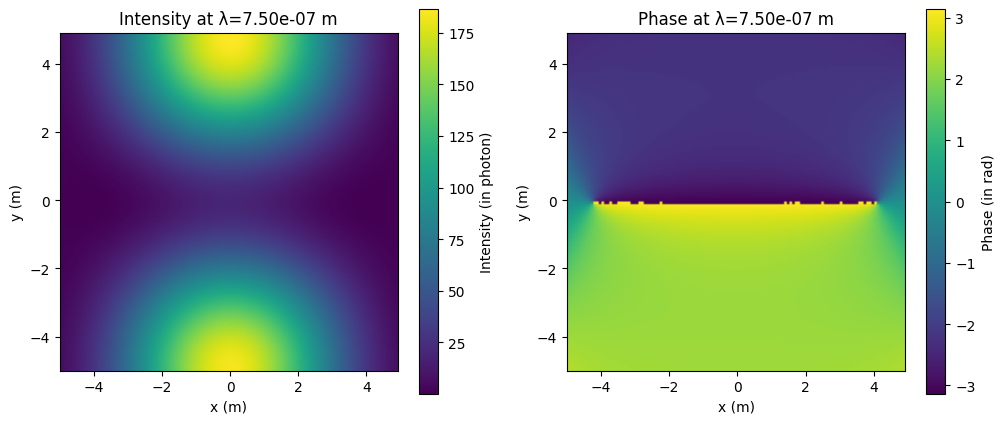

In [18]:
# Create input field
field = source.generate_field(pupil_grid)
field.plot()

# Apply aperture
field = aperture.apply(field)
field.plot()

aperture_field = field

# Propagate to focal plane
field = mft.propagate(field, focal_grid)
field.plot()


plt.figure()
plt.imshow(torch.abs(field.complex_amplitude).sum(dim=0))


# Apply aperture
field = zelda_stop.apply(field)
field.plot()

# Propagate to pupil plane
field = mft.propagate(field, pupil_grid)
field.plot()
b = field

In [19]:
Phi = aperture.apply(aperture_field - (1 - torch.exp(1j * theta)) * b)

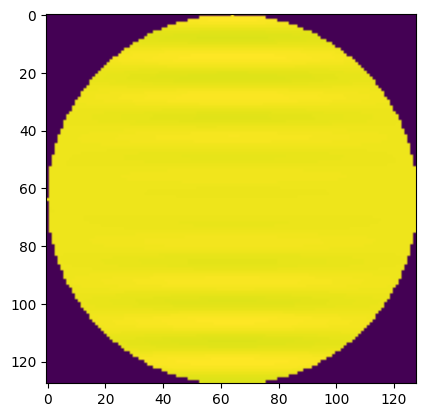

In [20]:
plt.imshow(Phi.complex_amplitude.abs()[0])